## 1. Data Acquisition & Loading
Dataset source: [Amazon Product Reviews](https://www.kaggle.com/datasets/tarkkaanko/amazon)  
Contains 4,915 reviews for a single SanDisk SD card product, spanning January 2012 to December 2014.

In [5]:
import pandas as pd
df = pd.read_csv('data/amazon_reviews.csv')
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


## 2. Exploratory Data Analysis (EDA)
Initial inspection of data shape, time range, and missing values before cleaning.

In [6]:
print(df.shape)
print(df['reviewTime'].min(),df['reviewTime'].max())
df.info()
print(df.isnull().sum())

(4915, 12)
2012-01-09 2014-12-07
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   float64
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 460.9+ KB
Unnamed: 0              0
reviewerName            1
overall                 0
revi

**Observations:**
- Dataset contains 4,915 reviews across 12 columns, spanning January 2012 to December 2014 (approximately 3 years)
- Key columns for this analysis: `reviewText` (sentiment input), `overall` (star rating), `reviewTime` (time series)
- Two data quality issues identified: 1 missing value in `reviewText`, and `reviewTime` stored as string rather than datetime format — both addressed in Section 3

## 3. Data Cleaning

Two cleaning steps are required based on EDA findings:
1. Drop the 1 row with missing `reviewText` — cannot perform sentiment analysis without review content
2. Convert `reviewTime` from string to datetime format — required for time series aggregation later

Note: `reviewerName` also has 1 missing value but is not used in this analysis, so no action needed.

In [7]:
df = df.dropna(subset=['reviewText'])
df['reviewTime'] = pd.to_datetime(df['reviewTime'])

## 4. Sentiment Analysis

Each review is scored using VADER (Valence Aware Dictionary and sEntiment Reasoner), a rule-based sentiment analysis tool that assigns a compound score ranging from -1 (most negative) to +1 (most positive).

VADER was chosen for this analysis because:
- No training required — scores are based on a pre-built lexicon of ~7,500 words
- Lightweight and interpretable — scoring logic is fully explainable
- Sufficient for product review text — performs well on short, informal consumer language

A compound score ≥ 0.05 is classified as positive, ≤ -0.05 as negative, and between -0.05 and 0.05 as neutral.

In [8]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00


In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

### 4.1 VADER Behavior Validation

Before applying VADER to the full dataset, we test its behavior on selected examples to build intuition and identify potential failure patterns.

In [10]:
#Expected positive -- verify VADER scores correctly
print(analyzer.polarity_scores("This product is amazing, I love it!"))

#Expected negative -- verify VADER scores correctly
print(analyzer.polarity_scores("This is terrible, worst purchase ever."))

#Calm narrative negative -- no strong emotion words,may confuse VADER
print(analyzer.polarity_scores("It stopped working after one day"))

#Negation pattern investigation -- "no issues" should be positive
print(analyzer.polarity_scores("issues"))       # isolated word
print(analyzer.polarity_scores("No issues"))    # negation + neutral noun
print(analyzer.polarity_scores("No issues."))   # with punctuation
print(analyzer.polarity_scores("no problem"))   # control comparison
print(analyzer.polarity_scores("no"))           # isolated negation word

{'neg': 0.0, 'neu': 0.376, 'pos': 0.624, 'compound': 0.8516}
{'neg': 0.643, 'neu': 0.357, 'pos': 0.0, 'compound': -0.802}
{'neg': 0.275, 'neu': 0.725, 'pos': 0.0, 'compound': -0.2263}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
{'neg': 0.688, 'neu': 0.312, 'pos': 0.0, 'compound': -0.296}
{'neg': 0.688, 'neu': 0.312, 'pos': 0.0, 'compound': -0.296}
{'neg': 0.0, 'neu': 0.307, 'pos': 0.693, 'compound': 0.3089}
{'neg': 1.0, 'neu': 0.0, 'pos': 0.0, 'compound': -0.296}


**Finding:** "no" is stored as a negative word in VADER's lexicon (-0.296), while "issues" is neutral (0.0). When combined as "No issues", VADER's negation-handling mechanism fails to reverse the sentiment because there is no negative word to negate — instead, "no" simply contributes its own negative score. This reveals a core limitation: **VADER sums word-level scores without understanding sentence-level logic.**

### 4.2 Scoring Full Dataset

Apply VADER to every review in the dataset using `.apply()`, extracting only the `compound` score for each row and storing it as a new column `sentiment_score`.

In [11]:
df['sentiment_score'] = df['reviewText'].apply(lambda text:analyzer.polarity_scores(text)['compound'])
df[['reviewText','overall','sentiment_score']].head(10)

,reviewText,overall,sentiment_score
0,No issues.,4.0,-0.2960
1,"Purchased this for my device, it worked as adv...",5.0,-0.2960
2,it works as expected. I should have sprung for...,4.0,-0.3089
3,This think has worked out great.Had a diff. br...,5.0,0.7081
4,"Bought it with Retail Packaging, arrived legit...",5.0,0.7087
5,It's mini storage. It doesn't do anything els...,5.0,0.0000
6,I have it in my phone and it never skips a bea...,5.0,0.8992
7,It's hard to believe how affordable digital ha...,5.0,0.6886
8,Works in a HTC Rezound. Was running short of ...,5.0,-0.2960
9,"in my galaxy s4, super fast card, and am total...",5.0,0.6840


**Output:** `sentiment_score` column added to dataframe. Scores range from -1.0 to +1.0, with the distribution examined in detail in Section 4.3.

### 4.3 Sentiment Score Distribution

The distribution of VADER compound scores across all 4,914 reviews is visualized to understand the overall sentiment profile of the dataset before proceeding to time series analysis.

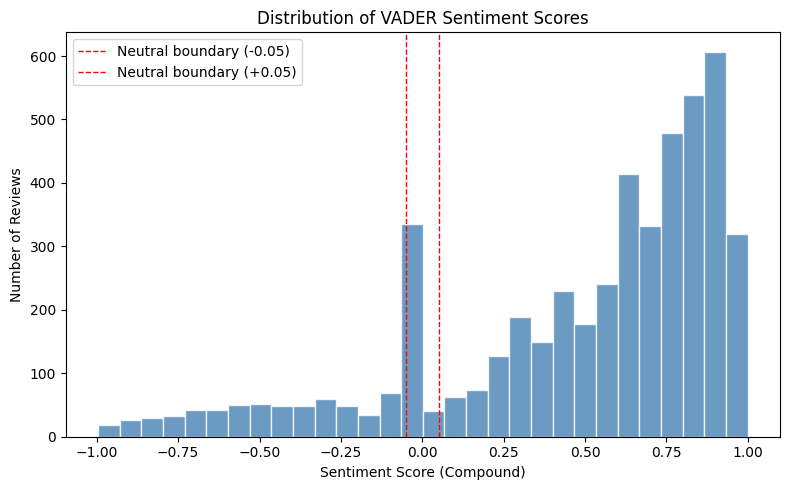

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['sentiment_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)

# mark the boundaries between negative/neutral/positive
ax.axvline(x=-0.05, color='red', linestyle='--', linewidth=1, label='Neutral boundary (-0.05)')
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=1, label='Neutral boundary (+0.05)')

ax.set_xlabel('Sentiment Score (Compound)')
ax.set_ylabel('Number of Reviews')
ax.set_title('Distribution of VADER Sentiment Scores')
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**
- The distribution is heavily right-skewed, with the majority of reviews scoring above 0.05 (positive) — consistent with the generally favorable reception of this product
- Negative reviews (score ≤ -0.05) are present but represent a small minority of the dataset
- A notable spike appears near 0 (between -0.05 and 0.05), disproportionately high compared to neighboring bins, creating a bimodal-like distribution alongside the main cluster at 0.6-1.0. This is consistent with the negation mishandling and weak positive failure patterns identified in Section 5 — reviews like "No issues" or "Works as expected" are systematically scored near zero despite conveying positive sentiment, and few reviews fall in the mildly positive range (0.05-0.4)

## 5. Manual Validation

To assess VADER's reliability on this dataset, 80 reviews were randomly sampled (random_state=42) and manually labeled as `positive`, `negative`, or `neutral` based on independent human judgment — without reference to VADER's scores.

The validation follows three steps:
1. Distribution comparison — compare human vs VADER label distributions
2. Agreement rate — calculate overall accuracy
3. Failure pattern analysis — identify and categorize mismatches

In [13]:
# Sample 80 reviews for manual validation
sample80 = df.sample(80, random_state=42)[['reviewText', 'overall', 'sentiment_score']].reset_index(drop=True)

# Load manually labeled results
validation_df = pd.read_excel('data/manual_validation.xlsx')

### 5.1 Distribution Comparison

Comparing the distribution of sentiment labels between human judgment and VADER classification to check for systematic bias.

In [14]:
# Human judgment distribution
print("Human judgment distribution:")
print(validation_df['my_judgment'].value_counts())

# VADER classification using standard thresholds
def classify_vader(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

validation_df['vader_judgment'] = validation_df['sentiment_score'].apply(classify_vader)

print("\nVADER classification distribution:")
print(validation_df['vader_judgment'].value_counts())

Human judgment distribution:
my_judgment
positive    65
negative     8
neutral      7
Name: count, dtype: int64

VADER classification distribution:
vader_judgment
positive    63
negative    11
neutral      6
Name: count, dtype: int64


**Observations:**
- Human labels: 65 positive, 8 negative, 7 neutral
- VADER labels: 63 positive, 11 negative, 6 neutral
- Overall distribution is closely aligned — both human and VADER identify the dataset as predominantly positive (~80%), reflecting the generally favorable reviews for this product
- VADER tends to slightly over-classify reviews as negative (11 vs 8) and under-classify as positive (63 vs 65) — suggesting a systematic negative bias, explored further in Section 5.3

### 5.2 Agreement Rate

Overall accuracy is calculated by comparing human judgment against VADER classification for all 80 samples.

In [15]:
#Calculate agreement rate
validation_df['match'] = validation_df['vader_judgment'] == validation_df['my_judgment']

agreement_rate = validation_df['match'].mean()
print(f"Overall agreement rate: {agreement_rate:.1%}")
print(f"Matched:{validation_df['match'].sum()}/{len(validation_df)}")

Overall agreement rate: 80.0%
Matched:64/80


**Observations:**
- Overall agreement rate: 80.0% (64/80 samples matched)
- 16 mismatches were identified for further analysis in Section 5.3
- An 80% agreement rate indicates VADER is directionally reliable for trend-level analysis, but individual scores contain noise — conclusions drawn from aggregated monthly data are more trustworthy than conclusions drawn from any single review's score

### 5.3 Failure Pattern Analysis
Examining the 16 mismatches to identify systematic failure patterns in VADER's classification.

In [16]:
mismatches = validation_df[validation_df['match'] == False]
mismatches[['reviewText','overall','sentiment_score','vader_judgment','my_judgment']]

,reviewText,overall,sentiment_score,vader_judgment,my_judgment
1,I purchased this product knowing there might b...,1,0.5962,positive,negative
3,This was an inexpensive way to get my Galaxy N...,5,0.0000,neutral,positive
4,Purchased two 32 GBcards for the two new Sams...,4,-0.2960,negative,positive
6,good scan disk but the wrong one for my camera...,4,-0.7184,negative,neutral
9,"Works as advertised, no issues to date. There...",5,-0.2960,negative,positive
10,...and they're right!This microSDHC card is fa...,5,-0.7262,negative,positive
11,Once I figured out the S3 wasn't liking the ex...,4,0.9595,positive,neutral
16,"I've used many others, and this is average. It...",4,0.6705,positive,neutral
19,I bought this the day it came out for the grea...,5,0.3716,positive,neutral
23,I bought the Sandisk Ultra 32gb card for use i...,1,0.5279,positive,negative


In [17]:
mismatches = mismatches.copy()
mismatches['failure_pattern'] = [
    'transitional negative',   # row 1
    'weak positive missed',    # row 3
    'negation mishandling',    # row 4
    'over-positive scoring',   # row 6
    'negation mishandling',    # row 9
    'non-emotional objective', # row 10
    'over-positive scoring',   # row 11
    'over-positive scoring',   # row 16
    'over-positive scoring',   # row 19
    'transitional negative',   # row 23
    'weak positive missed',    # row 46
    'weak positive missed',    # row 51
    'calm narrative negative', # row 52
    'negation mishandling',    # row 53
    'negation mishandling',    # row 67
    'non-emotional objective', # row 70
]

print(mismatches['failure_pattern'].value_counts())

failure_pattern
over-positive scoring      4
negation mishandling       4
weak positive missed       3
transitional negative      2
non-emotional objective    2
calm narrative negative    1
Name: count, dtype: int64


**Findings — 16 mismatches categorized into 6 failure patterns:**

| Failure Pattern | Count | Description |
|---|---|---|
| Over-positive scoring | 4 | VADER over-weights positive words in mixed or neutral reviews |
| Negation mishandling | 4 | "no issues" / "no problem" scored as negative — "no" treated as a standalone negative word |
| Weak positive missed | 3 | Positive reviews with no strong emotion words scored as neutral |
| Transitional negative | 2 | "Worked great...then broke" — early positive words outweigh later negative content |
| Non-emotional objective | 2 | Compatibility warnings or rhetorical statements incorrectly scored |
| Calm narrative negative | 1 | Negative experience described without strong emotion words, missed by VADER |

**Root cause:** All six failure patterns share the same underlying cause — **VADER scores words individually and sums them up without understanding sentence-level logic.** It cannot handle negation ("no issues"), temporal transitions ("worked great, then failed"), or the absence of explicit emotion words.

**Limitations of this validation:**
- The 80-sample validation was randomly drawn, which means rare failure patterns may be underrepresented. The six failure modes identified are based on observed errors in this sample, not an exhaustive taxonomy of all possible VADER limitations.
- Manual labels were assigned by a single annotator, which introduces subjectivity. A more rigorous validation would involve multiple annotators with inter-annotator agreement metrics.

**Implication for analysis:** Given the 80% agreement rate and the nature of these failure patterns (no systematic bias toward over-positive or over-negative), aggregated monthly sentiment scores are expected to be directionally reliable. Individual review scores should not be interpreted as precise measurements.

## 6. Time-based Aggregation (Monthly)

Raw review data contains significant noise — individual scores fluctuate day to day, making it difficult to identify meaningful trends. To smooth out this noise, reviews are grouped by month and aggregated into three metrics: average sentiment score, average star rating, and review count. This produces 36 monthly data points spanning January 2012 to December 2014.


### 6.1 Monthly Review Count Distribution
Checking the distribution of monthly review counts to assess data density before aggregation.

In [18]:
# Extract year-month period for monthly grouping
df['year_month'] = df['reviewTime'].dt.to_period('M')

# Check monthly review count distribution to assess data density
monthly_counts = df.groupby('year_month').size()
print(monthly_counts.describe())

count     36.000000
mean     136.500000
std       93.895839
min        7.000000
25%       44.000000
50%      184.500000
75%      216.500000
max      306.000000
dtype: float64


**Observations:**
- Average review count per month: 136.5, but with high variance (std=93.9), ranging from 7 to 306
- Low sample months (n<40) are concentrated in January to August 2012, likely reflecting the product's initial launch phase
- **Decision:** Retain all 36 months but flag 2012-01 to 2012-08 in visualizations — fluctuations in this period may reflect sampling noise rather than genuine sentiment shifts

### 6.2 Monthly Aggregation Results

In [19]:
# Aggregate reviews by month — compute average sentiment, average rating, and review count
monthly_summary = df.groupby('year_month').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    avg_rating=('overall', 'mean'),
    review_count=('reviewText', 'count')
).reset_index()

print(monthly_summary.shape)
monthly_summary.head()

(36, 4)


,year_month,avg_sentiment,avg_rating,review_count
0,2012-01,0.390073,5.000000,11
1,2012-02,0.499965,4.352941,17
2,2012-03,0.659871,4.857143,7
3,2012-04,0.139373,4.181818,11
4,2012-05,0.289706,4.235294,17


**Output:** 36 monthly data points, each containing average sentiment score, average star rating, and review count — ready for trend visualization and lag correlation analysis.

### 6.3 Review Count Visualization

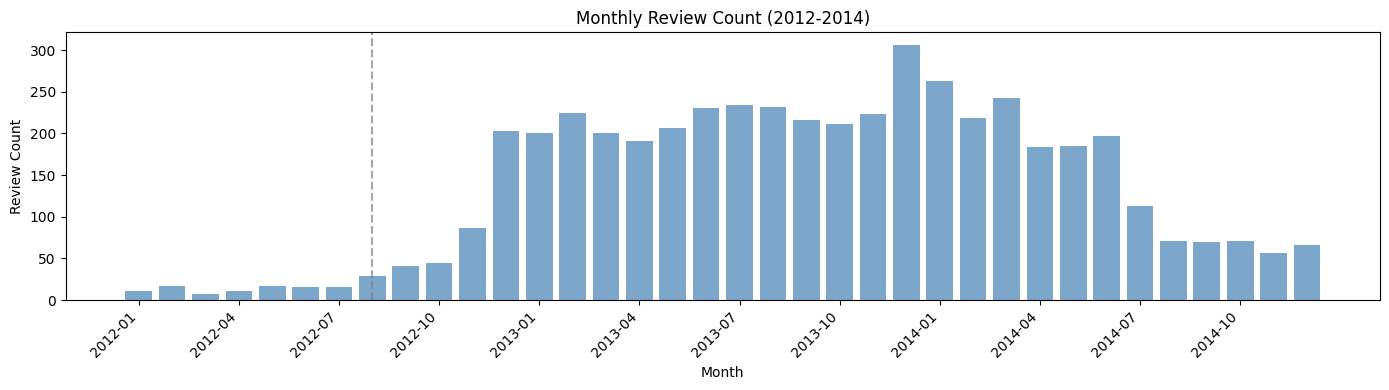

In [20]:
# visualize monthly review count to confirm low-sample period identified earlier
fig, ax = plt.subplots(figsize=(14, 4))
x = monthly_summary['year_month'].astype(str)
ax.bar(x, monthly_summary['review_count'], color='steelblue', alpha=0.7)
ax.set_xlabel('Month')
ax.set_ylabel('Review Count')
ax.set_title('Monthly Review Count (2012-2014)')
ax.set_xticks(range(0, len(x), 3))
ax.set_xticklabels(x[::3], rotation=45, ha='right')
ax.axvline(x=list(x).index('2012-08'), color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Observations:**
- Review counts are heavily skewed toward 2013-2014, with early months containing fewer than 30 reviews each
- Volume peaks around late 2013 to early 2014, then gradually declines through 2014 — possibly indicating the product entering a later stage of its lifecycle or facing increased competition

## 7. Sentiment vs Rating Trend Analysis

This section examines whether monthly sentiment scores and star ratings move in tandem over time through three approaches:
1. **Dual-axis trend visualization** — visual inspection of co-movement patterns
2. **Direction consistency analysis** — quantifying how often sentiment and rating change in the same direction
3. **Meaningful divergence analysis** — filtering out noise to identify statistically meaningful divergences

### 7.1 Dual-axis Trend Visualization

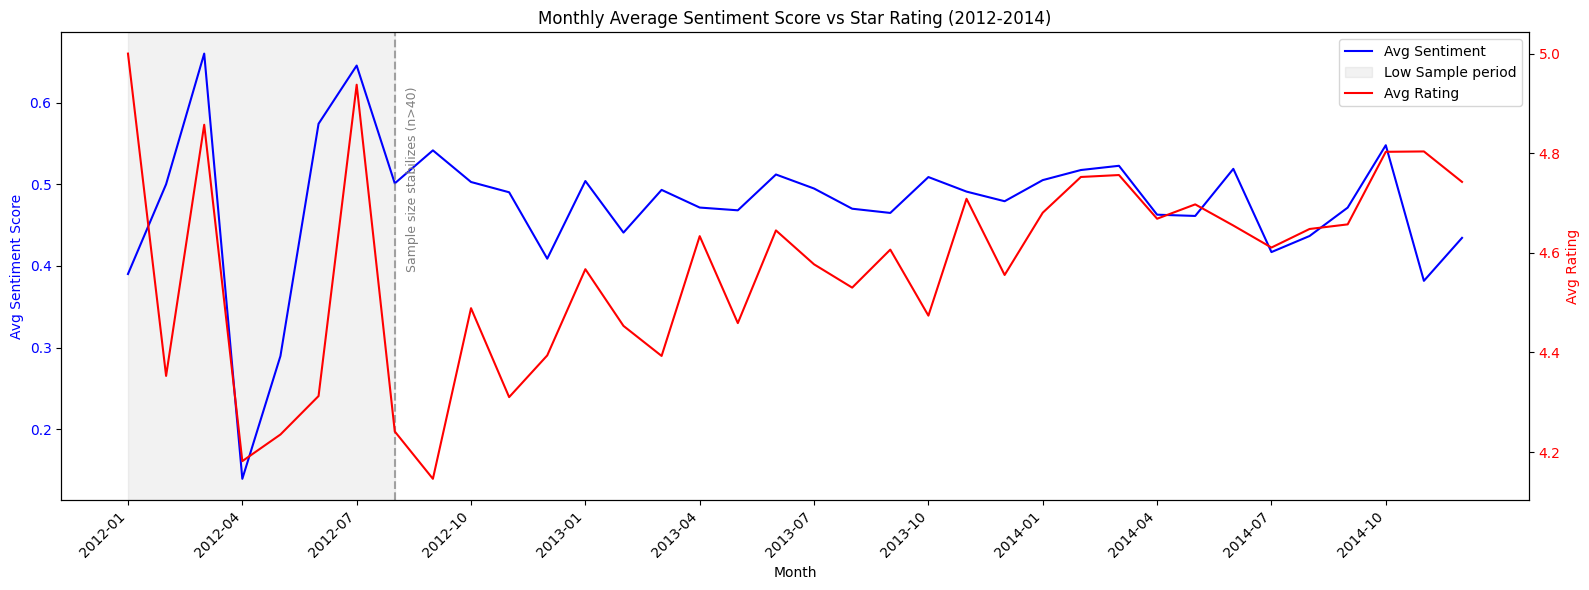

In [21]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(16, 6))
x = monthly_summary['year_month'].astype(str)  # convert Period to string for clean x-axis labels

# Plot sentiment score on left y-axis
ax1.plot(x, monthly_summary['avg_sentiment'], color='blue', label='Avg Sentiment')
ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Sentiment Score', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')  # match axis color to line color for readability

# Plot star rating on independent right y-axis (dual-axis to handle different scales)
ax2 = ax1.twinx()
ax2.plot(x, monthly_summary['avg_rating'], color='red', label='Avg Rating')
ax2.set_ylabel('Avg Rating', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Show every 3rd month to avoid label overlap
ax1.set_xticks(range(0, len(x), 3))
ax1.set_xticklabels(x[::3], rotation=45, ha='right')

# Flag low-sample period (2012-01 to 2012-08) — fluctuations here may reflect noise not genuine trends
cutoff_index = list(x).index('2012-08')
ax1.axvspan(0, cutoff_index, alpha=0.1, color='gray', label='Low Sample period')
ax1.axvline(x=cutoff_index, color='gray', linestyle='--', alpha=0.7)
ax1.text(cutoff_index + 0.3, 0.62, 'Sample size stabilizes (n>40)',
         rotation=90, va='top', ha='left', fontsize=9, color='gray')

# Merge legends from both axes into one box
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.title('Monthly Average Sentiment Score vs Star Rating (2012-2014)')
fig.tight_layout()
plt.show()

**Observations:**
- Both sentiment and rating show high volatility in the low-sample period (2012-01 to 2012-08), consistent with the sampling noise identified earlier
- From late 2012 onward, both metrics stabilize and show broadly similar movement patterns, with some periods of apparent synchronization and occasional divergence
- However, visual inspection alone is insufficient to determine whether sentiment leads, lags, or moves in sync with rating — a quantitative approach is required, which is addressed in Sections 8 and 9
- From late 2012 onward, both metrics stabilize and show broadly similar movement patterns. Notably, the two lines appear to converge more closely in 2014, suggesting increasing synchronization as the product matured

### 7.2 Direction Consistency Analysis

Monthly changes in sentiment and rating are calculated using `.diff()`. The product of the two changes determines directional agreement — same direction yields a positive product, opposite directions yield a negative product.

In [22]:
monthly_summary['sentiment_change'] = monthly_summary['avg_sentiment'].diff()
monthly_summary['rating_change'] = monthly_summary['avg_rating'].diff()
monthly_summary['same_direction'] = (monthly_summary['sentiment_change'] * monthly_summary['rating_change']) > 0

print(f"Total months: {len(monthly_summary) - 1}")  # exclude first row (NaN from diff())
print(f"Same direction: {monthly_summary['same_direction'].sum()}")
print(f"Opposite direction: {(~monthly_summary['same_direction']).sum() - 1}")  # exclude NaN row
print(f"Agreement rate: {monthly_summary['same_direction'].mean():.1%}")

Total months: 35
Same direction: 22
Opposite direction: 13
Agreement rate: 61.1%


**Observations:**
- Out of 35 valid months, 22 moved in the same direction (63%) and 13 in opposite directions (37%)
- However, this method has a methodological flaw — months where both changes are close to zero are counted as either "same direction" or "opposite direction" regardless of whether the change is meaningful
- Small, near-zero changes on both sides can produce misleading results — a change of +0.001 vs -0.001 is technically "opposite direction" but practically insignificant
- This issue is addressed in Section 7.3 by filtering out low-magnitude changes before calculating directional agreement

### 7.3 Meaningful Divergence Analysis

To address the methodological flaw identified in Section 7.2, months with low-magnitude changes are filtered out before calculating directional agreement. Only months where both sentiment and rating changed significantly are retained, using 0.5 standard deviations of each metric's change distribution as the threshold.

In [23]:
sentiment_std = monthly_summary['sentiment_change'].std()
rating_std = monthly_summary['rating_change'].std()

sentiment_threshold = sentiment_std * 0.5  # 0.5 SD as threshold for meaningful change
rating_threshold = rating_std * 0.5

significant_months = monthly_summary[
    (monthly_summary['sentiment_change'].abs() > sentiment_threshold) &
    (monthly_summary['rating_change'].abs() > rating_threshold)
]

print(f"Significant months: {len(significant_months)} / {len(monthly_summary) - 1}")
print(significant_months['same_direction'].value_counts())

significant_months[['year_month', 'avg_sentiment', 'avg_rating',
                     'sentiment_change', 'rating_change', 'same_direction']]

Significant months: 7 / 35
same_direction
True     6
False    1
Name: count, dtype: int64


,year_month,avg_sentiment,avg_rating,sentiment_change,rating_change,same_direction
1,2012-02,0.499965,4.352941,0.109892,-0.647059,False
2,2012-03,0.659871,4.857143,0.159907,0.504202,True
3,2012-04,0.139373,4.181818,-0.520499,-0.675325,True
6,2012-07,0.645225,4.937500,0.071225,0.625000,True
7,2012-08,0.501024,4.241379,-0.144201,-0.696121,True
12,2013-01,0.503899,4.567164,0.095075,0.173076,True
33,2014-10,0.547706,4.802817,0.076378,0.145674,True


**Observations:**
- After filtering, only 7 out of 35 months show meaningful changes in both metrics — among these, 6 moved in the same direction (86%) and only 1 diverged
- This is a stronger signal than the raw 63% from Section 7.2 — when both metrics actually moved meaningfully, they were highly likely to move together
- **However, the reliability of this finding is further undermined:** 5 out of 7 significant months fall within the low-sample period (2012-01 to 2012-08), suggesting these "meaningful changes" may themselves be artifacts of sampling noise. Among stable-sample months (2012-09 onward), only 2013-01 and 2014-10 qualify as meaningful
- **Overall:** The low number of truly meaningful months in the stable period (2 out of 28 = 7%) reflects the product's remarkably stable reputation — large swings in either metric were rare, making trend analysis inherently limited on this dataset

## 8. Lag Correlation Analysis

Section 7 identified directional co-movement between sentiment and rating, but could only use 7 meaningful months — insufficient to draw robust conclusions. Lag correlation addresses this by utilizing all 36 monthly data points.

The approach shifts `avg_sentiment` forward by 0 to 4 months and calculates the Pearson correlation coefficient between the shifted sentiment and `avg_rating` at each lag. By comparing correlation strength across different lags, we can determine whether sentiment leads, lags, or moves in sync with rating.

A p-value threshold of 0.05 is applied to distinguish statistically significant correlations from noise.

### 8.1 Correlation Results

In [24]:
from scipy.stats import pearsonr

results = []
for lag in range(0, 5):
    sentiment_shifted = monthly_summary['avg_sentiment'].shift(lag)
    valid = monthly_summary[['avg_rating']].join(sentiment_shifted.rename('shifted')).dropna()
    corr, pvalue = pearsonr(valid['shifted'], valid['avg_rating'])
    results.append({'lag': lag, 'correlation': round(corr, 4), 'p_value': round(pvalue, 4)})

lag_df = pd.DataFrame(results)
print(lag_df)

   lag  correlation  p_value
0    0       0.3332   0.0470
1    1       0.1444   0.4079
2    2      -0.3293   0.0572
3    3      -0.2576   0.1479
4    4       0.4030   0.0222


**Observations:**

| Lag | Correlation | p-value | Significant |
|---|---|---|---|
| 0 | 0.3332 | 0.047 | ✅ |
| 1 | 0.1444 | 0.408 | ❌ |
| 2 | -0.3293 | 0.057 | ❌ |
| 3 | -0.2576 | 0.148 | ❌ |
| 4 | 0.4030 | 0.022 | ✅ |

- **lag=0 is significant (r=0.33, p=0.047):** Sentiment and rating are positively correlated within the same month, supporting a synchronization relationship
- **lag=1, 2, 3 are not significant:** Sentiment does not statistically predict rating 1-3 months ahead — no short-term leading relationship exists
- **lag=2 and lag=3 turn negative** — explained by mean reversion: since sentiment and rating move synchronously, shifting sentiment forward means comparing past elevated sentiment against ratings that have already returned to baseline, producing a negative correlation
- **lag=4 is significant (r=0.40, p=0.022), but requires caution:** The return to positive correlation likely reflects a new seasonal co-movement cycle rather than a genuine 4-month leading relationship. Additionally, lag=4 reduces the usable sample to 32 months, limiting robustness


### 8.2 Visualization

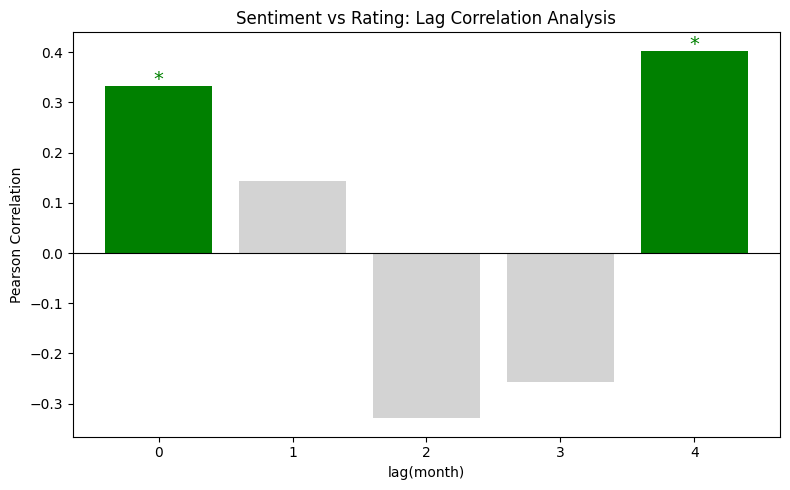

In [25]:
fig,ax = plt.subplots(figsize = (8,5))

ax.bar(lag_df['lag'],lag_df['correlation'],color = ['green' if p < 0.05 else 'lightgray' for p in lag_df['p_value']])
ax.axhline(y=0,color='black',linewidth=0.8)

ax.set_xlabel('lag(month)')
ax.set_ylabel('Pearson Correlation')
ax.set_title('Sentiment vs Rating: Lag Correlation Analysis')
ax.set_xticks(lag_df['lag'])

# add * marker above significant bars
for i,row in lag_df.iterrows():
    marker = '*' if row['p_value'] < 0.05 else ''
    ax.text(row['lag'],row['correlation'] + 0.002,marker,ha='center',fontsize=14,color='green')

plt.tight_layout()
plt.show()

**Observations:**
- Green bars (lag=0 and lag=4) are statistically significant; grey bars (lag=1, 2, 3) are not
- The visual pattern — positive, weakening, negative, negative, positive — is consistent with mean reversion followed by a new seasonal cycle, not a genuine leading relationship
- **Overall conclusion:** Sentiment co-moves with rating rather than predicting it. The evidence does not support using sentiment as a short-term leading indicator for rating changes


## 9. Conclusion

### 9.1 Key Findings

This project investigated whether customer review sentiment could serve as a leading indicator for star rating changes on an Amazon SD card product, using 4,914 reviews spanning January 2012 to December 2014.

**Main finding:** Sentiment and rating move synchronously — sentiment does not lead rating changes.

This conclusion is supported by two independent analyses:
- **Direction consistency analysis (Section 7):** Among months with statistically meaningful changes in both metrics, 86% showed synchronized movement. However, only 2 out of 28 stable-sample months qualified as "meaningful" — reflecting the product's overall stability rather than a lack of relationship
- **Lag correlation analysis (Section 8):** Only lag=0 produced a statistically significant positive correlation (r=0.33, p=0.047). Lag=1 to lag=3 were not significant, confirming no short-term leading relationship exists. The significant result at lag=4 is attributed to seasonal co-movement rather than a genuine causal relationship

**Business implication:** For this product, VOC sentiment analysis is not suitable as a predictive early-warning tool. It is more appropriately used as a real-time monitoring indicator alongside star ratings, for two reasons:

- **Neither metric is sufficient alone:** Sentiment scores can be noisy (20% misclassification rate) and miss "silent dissatisfaction" — users who give low ratings without writing reviews. Star ratings, on the other hand, can be pulled down by a small number of extreme scores without reflecting the majority's experience. Each metric has blind spots the other can partially compensate for.

- **Corroborating signals are more actionable:** When sentiment and rating simultaneously signal a negative trend, the combined signal is more reliable than either alone. For example, if average sentiment drops below 0.40 and average rating falls below 4.3 for two consecutive months, this dual signal could trigger a review of product quality or customer service response — whereas a drop in only one metric warrants monitoring but not immediate action.

### 9.2 Limitations

| Category | Limitation |
|---|---|
| Model | VADER scores words individually without understanding sentence-level logic — 80% agreement rate with human judgment, with known failure patterns in negation, transitional structures, and calm narrative negatives |
| Data | Monthly review counts are highly uneven (7 to 306 per month); early months (2012-01 to 2012-08) have insufficient samples for reliable trend analysis |
| Sample | Manual validation used a single annotator and 80 randomly sampled reviews — rare failure patterns may be underrepresented |
| Scope | Analysis is limited to a single product category (SD cards) over a 3-year period — findings may not generalize to other product types or time periods |
| Method | Lag correlation cannot distinguish genuine leading relationships from seasonal co-movement patterns without additional seasonal decomposition |

### 9.3 Future Directions

- Apply seasonal decomposition (e.g. STL decomposition) before lag correlation to control for seasonal effects and obtain a cleaner signal
- Expand to multiple product categories to test whether the synchronization finding generalizes
- Replace VADER with a transformer-based model (e.g. RoBERTa fine-tuned on product reviews) to reduce sentiment scoring noise and improve failure pattern coverage